In [1]:
from load_data import load_raw_data
from clean_data import clean_data
from split_data import split_data
from build_pipeline import build_pipeline
from evaluate_model import evaluate_model
from feature_engineering import build_new_features
from config import RANDOM_STATE
import logging

In [2]:
logging.basicConfig(
    level=logging.INFO,format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

In [3]:
# Loading raw data
dataset=load_raw_data()

2026-08-31 16:28:04,015 | INFO | load_data | Raw dataset loaded.


In [4]:
# Cleaning data
dataset_cleaned=clean_data(dataset, save=False)

2026-08-31 16:28:04,019 | INFO | clean_data | Dropped customerID.
2026-08-31 16:28:04,021 | INFO | clean_data | Converted TotalCharges to numeric.
2026-08-31 16:28:04,024 | INFO | clean_data | Rows containing NaN before cleaning: 11
2026-08-31 16:28:04,031 | INFO | clean_data | Removed 11 rows with invalid TotalCharges. Remaining rows with NaN: 0.


In [5]:
# Adding new features
#dataset_cleaned=build_new_features(dataset_cleaned, new_features=["NumberServices","CustomerLevel","MonthlyChargePerService","AverageMonthlyCharge"])

In [6]:
# Splitting data
X_train, X_test, y_train, y_test=split_data(dataset_cleaned, random_state=RANDOM_STATE)

2026-08-31 16:28:04,055 | INFO | split_data | Data split into train/test set with 0.8/0.2 proportion and random_state=0.


### XGBoost

In [7]:
# Building XGBoost model
pipe_XBG=build_pipeline(trial=None,model='XGBoost')
fitted_pipe_XBG=pipe_XBG.fit(X_train, y_train)

### Logistic Regression

In [8]:
# Building Logistic Regression model
pipe_LR=build_pipeline(trial=None,model='Logistic Regression')
fitted_pipe_LR=pipe_LR.fit(X_train, y_train)

### K-Nearest Neighbors

In [9]:
# Building K-Nearest Neighbors
pipe_KNN=build_pipeline(trial=None,model='K-Nearest Neighbors')
fitted_pipe_KNN=pipe_KNN.fit(X_train, y_train)

### Support Vector Machine

In [10]:
# Building Support Vector Machine model
pipe_SVM=build_pipeline(trial=None,model='Support Vector Machine')
fitted_pipe_SVM=pipe_SVM.fit(X_train, y_train)

### Decision Tree

In [11]:
# Building Decision Tree model
pipe_DT=build_pipeline(trial=None,model='Decision Tree')
fitted_pipe_DT=pipe_DT.fit(X_train, y_train)

### Random Forest

In [12]:
# Building Random Forest model
pipe_RF=build_pipeline(trial=None,model='Random Forest')
fitted_pipe_RF=pipe_RF.fit(X_train, y_train)

### Model performances

2026-08-31 16:28:08,908 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for XGBClassifier classification model.


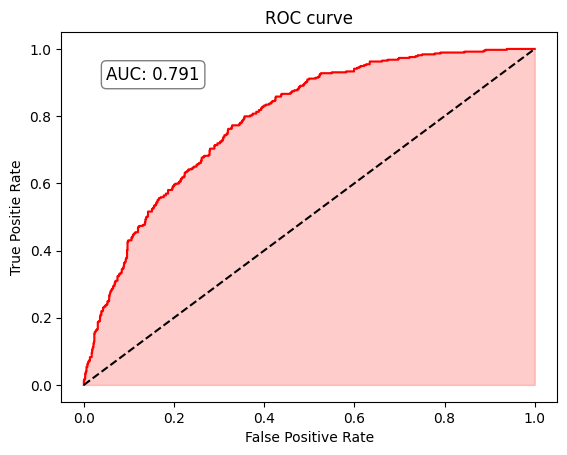

{'classifier_name': 'XGBClassifier',
 'accuracy': 0.767,
 'f1': 0.519,
 'precision': 0.575,
 'recall': 0.473,
 'roc_auc': 0.791,
 'average_precision': 0.553,
 'confusion_matrix': array([[902, 131],
        [197, 177]])}

In [13]:
# Evaluate model performance
metrics_XBG,report_XBG=evaluate_model(fitted_pipe_XBG,X_test,y_test)
metrics_XBG

2026-08-31 16:28:09,038 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for LogisticRegression classification model.


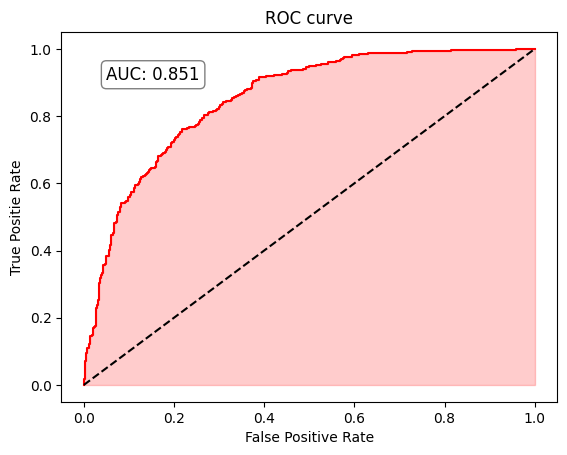

{'classifier_name': 'LogisticRegression',
 'accuracy': 0.753,
 'f1': 0.631,
 'precision': 0.524,
 'recall': 0.794,
 'roc_auc': 0.851,
 'average_precision': 0.658,
 'confusion_matrix': array([[763, 270],
        [ 77, 297]])}

In [14]:
metrics_LR,report_LR=evaluate_model(fitted_pipe_LR,X_test,y_test)
metrics_LR

2026-08-31 16:28:09,178 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for KNeighborsClassifier classification model.


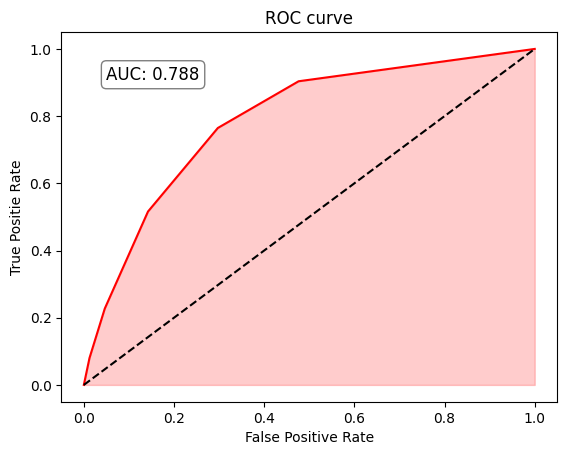

{'classifier_name': 'KNeighborsClassifier',
 'accuracy': 0.767,
 'f1': 0.541,
 'precision': 0.568,
 'recall': 0.516,
 'roc_auc': 0.788,
 'average_precision': 0.516,
 'confusion_matrix': array([[886, 147],
        [181, 193]])}

In [15]:
metrics_KNN,report_KNN=evaluate_model(fitted_pipe_KNN,X_test,y_test)
metrics_KNN

2026-08-31 16:28:09,643 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for SVC classification model.


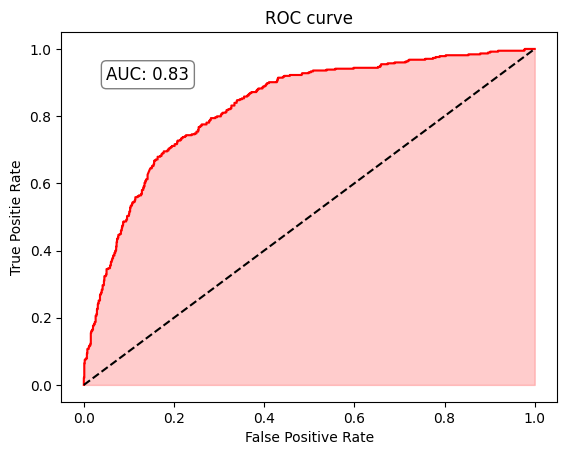

{'classifier_name': 'SVC',
 'accuracy': 0.749,
 'f1': 0.619,
 'precision': 0.519,
 'recall': 0.767,
 'roc_auc': 0.83,
 'average_precision': 0.638,
 'confusion_matrix': array([[767, 266],
        [ 87, 287]])}

In [16]:
metrics_SVM,report_SVM=evaluate_model(fitted_pipe_SVM,X_test,y_test)
metrics_SVM

2026-08-31 16:28:09,741 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for DecisionTreeClassifier classification model.


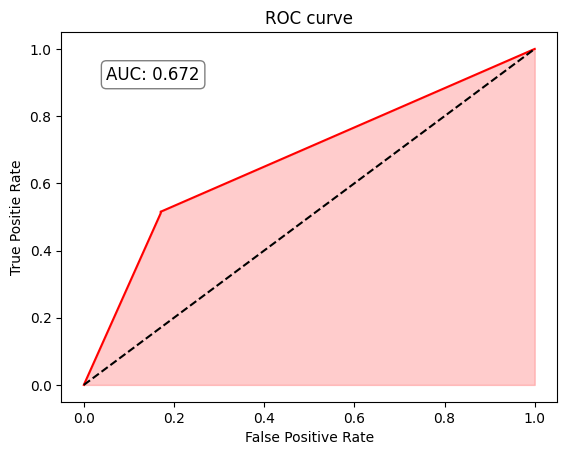

{'classifier_name': 'DecisionTreeClassifier',
 'accuracy': 0.746,
 'f1': 0.519,
 'precision': 0.522,
 'recall': 0.516,
 'roc_auc': 0.672,
 'average_precision': 0.397,
 'confusion_matrix': array([[856, 177],
        [181, 193]])}

In [17]:
metrics_DT,report_DT=evaluate_model(fitted_pipe_DT,X_test,y_test)
metrics_DT

2026-08-31 16:28:09,874 | INFO | evaluate_model | Calculated accuracy, roc_auc, f_1, precision, recall, average_precision, confusion_matrix and report for RandomForestClassifier classification model.


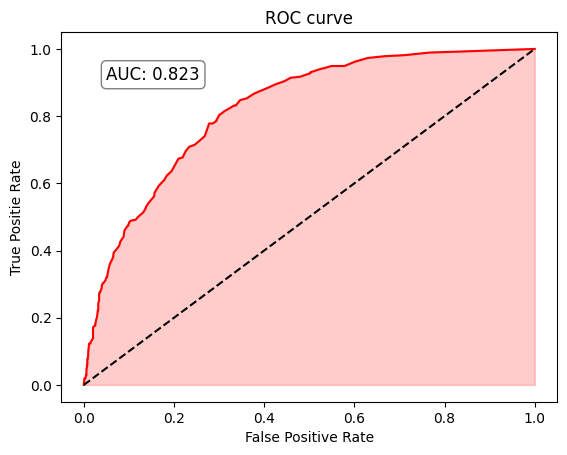

{'classifier_name': 'RandomForestClassifier',
 'accuracy': 0.79,
 'f1': 0.538,
 'precision': 0.649,
 'recall': 0.46,
 'roc_auc': 0.823,
 'average_precision': 0.602,
 'confusion_matrix': array([[940,  93],
        [202, 172]])}

In [18]:
metrics_RF,report_RF=evaluate_model(fitted_pipe_RF,X_test,y_test)
metrics_RF